# 5 · Validación y comparación de modelos
## WiDS Datathon 2026 — Data Wizards

¿Es confiable nuestro C-index de ~0.95? Este notebook cierra la defensa con cuatro
comprobaciones:

1. **Comparación unificada** de los 3 modelos (KM, RSF, Cox) con las mismas métricas.
2. **Nested vs Flat CV** — cuánto infla la métrica seleccionar features mirando todo el train.
3. **Adversarial validation** — ¿el CV en train predice el test?
4. **Monotonicidad** de las predicciones por horizonte.

In [1]:
import sys
from pathlib import Path

_SRC = next((p for p in ["src", "../src"] if (Path(p) / "wids_common.py").exists()), None)
if _SRC and _SRC not in sys.path:
    sys.path.insert(0, _SRC)

import warnings
warnings.filterwarnings("ignore")
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

from lifelines import CoxPHFitter, KaplanMeierFitter
from sksurv.util import Surv
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import brier_score, integrated_brier_score, concordance_index_censored
from statsmodels.stats.outliers_influence import variance_inflation_factor

from wids_common import (
    load_data, setup_style, feature_universe, safe_times, stepfn_to_matrix,
    assign_quartile, COX_FEATURES, RSF_FEATURES, HORIZONS, HORIZON_COLS,
)

PALETTE, C0, C1, C2, C3 = setup_style()
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)

df_train, df_test = load_data()
ALL_FEATURES = feature_universe(df_train, df_test)
strat = df_train["event"].astype(int)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
RSF_PARAMS = dict(n_estimators=300, min_samples_leaf=10, max_features=0.5, n_jobs=-1, random_state=42)

## 5.1 Comparación unificada de los 3 modelos

Mismo CV 5-fold para los tres, con C-index (orden) e IBS (calibración).

- **KM estratificado** por cuartil de `log(dist)`: referencia no-paramétrica.
- **RSF** (24 features) y **Cox** (11 features): nuestros modelos.

Modelo  C_index  C_std    IBS
    KM   0.8829 0.0177 0.0787
   RSF   0.9481 0.0049 0.0304
   Cox   0.9217 0.0202 0.0654


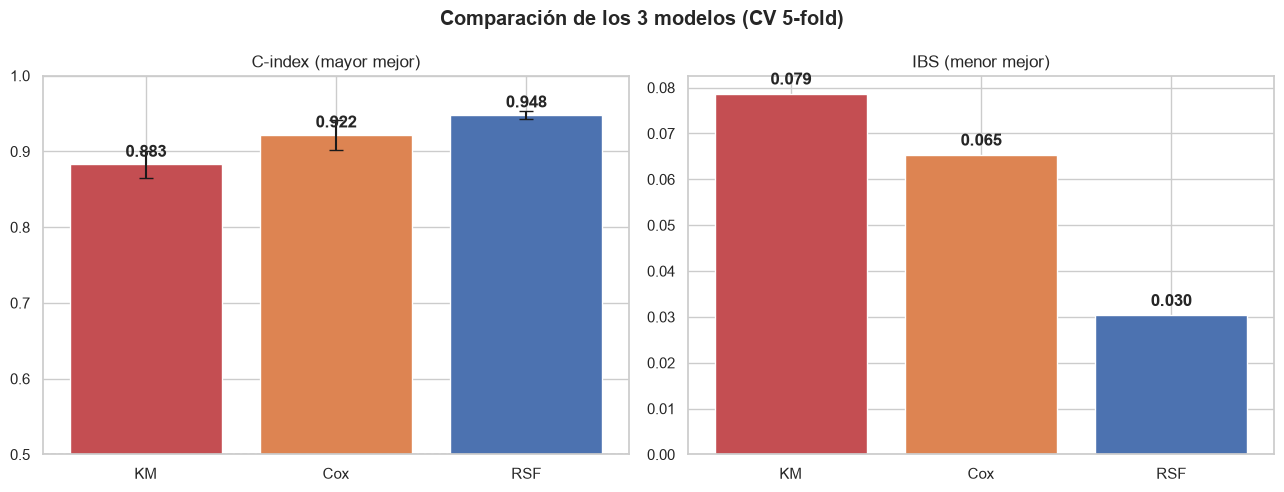

In [2]:
def km_curves(df_tr, times):
    log_dist = np.log1p(df_tr["dist_min_ci_0_5h"])
    edges = log_dist.quantile([0, .25, .5, .75, 1.0]).values
    q = assign_quartile(log_dist.values, edges)
    kmf = KaplanMeierFitter()
    curve = {}
    for k in range(4):
        mask = q == k
        if mask.sum() == 0:
            curve[k] = {t: 1.0 for t in times}
        else:
            kmf.fit(df_tr.loc[mask, "time_to_hit_hours"], df_tr.loc[mask, "event"])
            curve[k] = {t: float(kmf.predict(t)) for t in times}
    return curve, edges


records = {"KM": [], "RSF": [], "Cox": []}
for tr, va in skf.split(df_train, strat):
    df_tr, df_va = df_train.iloc[tr].reset_index(drop=True), df_train.iloc[va].reset_index(drop=True)
    y_tr = Surv.from_dataframe("event", "time_to_hit_hours", df_tr)
    y_va = Surv.from_dataframe("event", "time_to_hit_hours", df_va)
    tf = safe_times(y_tr, y_va)
    if not tf:
        continue

    # Cox (11)
    s = StandardScaler()
    Xtr = pd.DataFrame(s.fit_transform(df_tr[COX_FEATURES]), columns=COX_FEATURES)
    Xtr["time_to_hit_hours"] = df_tr["time_to_hit_hours"].values
    Xtr["event"] = df_tr["event"].values
    Xva = pd.DataFrame(s.transform(df_va[COX_FEATURES]), columns=COX_FEATURES)
    cph = CoxPHFitter(penalizer=0.05).fit(Xtr, duration_col="time_to_hit_hours", event_col="event")
    sf_cox = cph.predict_survival_function(Xva, times=tf).T.values
    risk_cox = 1 - cph.predict_survival_function(Xva, times=[max(tf)]).T.values[:, 0]
    records["Cox"].append({
        "C": concordance_index_censored(y_va["event"], y_va["time_to_hit_hours"], risk_cox)[0],
        "IBS": integrated_brier_score(y_tr, y_va, sf_cox, tf)})

    # RSF (24)
    rsf = RandomSurvivalForest(**RSF_PARAMS).fit(df_tr[RSF_FEATURES].astype(float).values, y_tr)
    sf_rsf = stepfn_to_matrix(rsf.predict_survival_function(df_va[RSF_FEATURES].astype(float).values), tf)
    risk_rsf = rsf.predict(df_va[RSF_FEATURES].astype(float).values)
    records["RSF"].append({
        "C": concordance_index_censored(y_va["event"], y_va["time_to_hit_hours"], risk_rsf)[0],
        "IBS": integrated_brier_score(y_tr, y_va, sf_rsf, tf)})

    # KM estratificado
    curve, edges = km_curves(df_tr, tf)
    va_q = assign_quartile(np.log1p(df_va["dist_min_ci_0_5h"].values), edges)
    sf_km = np.array([[curve[va_q[i]][t] for t in tf] for i in range(len(df_va))])
    risk_km = 1 - sf_km[:, -1]
    records["KM"].append({
        "C": concordance_index_censored(y_va["event"], y_va["time_to_hit_hours"], risk_km)[0],
        "IBS": integrated_brier_score(y_tr, y_va, sf_km, tf)})

summary = pd.DataFrame([
    {"Modelo": m, "C_index": np.mean([r["C"] for r in records[m]]),
     "C_std": np.std([r["C"] for r in records[m]]),
     "IBS": np.mean([r["IBS"] for r in records[m]])}
    for m in ["KM", "RSF", "Cox"]])
print(summary.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
order = ["KM", "Cox", "RSF"]
sub = summary.set_index("Modelo").loc[order]
axes[0].bar(order, sub["C_index"], yerr=sub["C_std"], capsize=5, color=[C3, C1, C0], edgecolor="white")
axes[0].set(title="C-index (mayor mejor)", ylim=(0.5, 1.0))
axes[0].axhline(0.5, color="gray", ls="--", lw=1)
for i, v in enumerate(sub["C_index"]):
    axes[0].text(i, v + 0.01, f"{v:.3f}", ha="center", fontweight="bold")
axes[1].bar(order, sub["IBS"], color=[C3, C1, C0], edgecolor="white")
axes[1].set(title="IBS (menor mejor)")
for i, v in enumerate(sub["IBS"]):
    axes[1].text(i, v + 0.002, f"{v:.3f}", ha="center", fontweight="bold")
plt.suptitle("Comparación de los 3 modelos (CV 5-fold)", fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "13_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

El **RSF** lidera el C-index y el IBS; el **Cox** queda muy cerca y aporta
interpretabilidad; el **KM** es una referencia decente pero solo asigna 4 valores
posibles por horizonte (un valor por cuartil), por eso no es el modelo final.

## 5.2 Nested CV vs Flat CV — el optimismo de la selección

Seleccionar features mirando **todo** el train y luego hacer CV (enfoque *flat*) deja
que los folds de validación influyan en qué features entran: hay fuga y la métrica sale
**optimista**. El enfoque honesto (*nested*) re-selecciona dentro de cada fold. La
diferencia flat − nested cuantifica ese optimismo.

In [3]:
def select_cox(df_fold):
    y = Surv.from_dataframe("event", "time_to_hit_hours", df_fold)
    Xs = pd.DataFrame(StandardScaler().fit_transform(df_fold[ALL_FEATURES]), columns=ALL_FEATURES)
    cand = []
    for f in ALL_FEATURES:
        try:
            d = pd.DataFrame({f: Xs[f].values,
                              "time_to_hit_hours": df_fold["time_to_hit_hours"].values,
                              "event": df_fold["event"].values})
            cph = CoxPHFitter(penalizer=0.1).fit(d, "time_to_hit_hours", "event")
            risk = cph.predict_partial_hazard(d).values
            if concordance_index_censored(y["event"], y["time_to_hit_hours"], risk)[0] >= 0.55:
                cand.append(f)
        except Exception:
            pass
    while len(cand) > 1:
        vifs = [variance_inflation_factor(Xs[cand].values, i) for i in range(len(cand))]
        if max(vifs) > 5:
            cand.pop(int(np.argmax(vifs)))
        else:
            break
    return cand


def select_rsf(df_fold):
    y = Surv.from_dataframe("event", "time_to_hit_hours", df_fold)
    X = df_fold[ALL_FEATURES].astype(float).values
    rsf = RandomSurvivalForest(n_estimators=200, min_samples_leaf=10, max_features=0.5,
                               n_jobs=-1, random_state=42).fit(X, y)
    pi = permutation_importance(rsf, X, y, n_repeats=10, random_state=42, n_jobs=-1)
    return [ALL_FEATURES[i] for i in range(len(ALL_FEATURES))
            if not (pi.importances_mean[i] == 0 and pi.importances_std[i] == 0)]


def eval_cox(df_tr, df_va, feats):
    s = StandardScaler()
    Xtr = pd.DataFrame(s.fit_transform(df_tr[feats]), columns=feats)
    Xtr["time_to_hit_hours"] = df_tr["time_to_hit_hours"].values
    Xtr["event"] = df_tr["event"].values
    Xva = pd.DataFrame(s.transform(df_va[feats]), columns=feats)
    cph = CoxPHFitter(penalizer=0.05).fit(Xtr, duration_col="time_to_hit_hours", event_col="event")
    risk = 1 - cph.predict_survival_function(Xva, times=[72]).T.values[:, 0]
    y_va = Surv.from_dataframe("event", "time_to_hit_hours", df_va)
    return concordance_index_censored(y_va["event"], y_va["time_to_hit_hours"], risk)[0]


def eval_rsf(df_tr, df_va, feats):
    y_tr = Surv.from_dataframe("event", "time_to_hit_hours", df_tr)
    y_va = Surv.from_dataframe("event", "time_to_hit_hours", df_va)
    rsf = RandomSurvivalForest(**RSF_PARAMS).fit(df_tr[feats].astype(float).values, y_tr)
    return concordance_index_censored(y_va["event"], y_va["time_to_hit_hours"],
                                      rsf.predict(df_va[feats].astype(float).values))[0]


res = {"cox_flat": [], "cox_nested": [], "rsf_flat": [], "rsf_nested": []}
cox_counter, cox_nfeat = Counter(), []
for fold, (tr, va) in enumerate(skf.split(df_train, strat), 1):
    df_tr, df_va = df_train.iloc[tr].reset_index(drop=True), df_train.iloc[va].reset_index(drop=True)
    res["cox_flat"].append(eval_cox(df_tr, df_va, COX_FEATURES))
    res["rsf_flat"].append(eval_rsf(df_tr, df_va, RSF_FEATURES))
    cox_f, rsf_f = select_cox(df_tr), select_rsf(df_tr)
    cox_counter.update(cox_f); cox_nfeat.append(len(cox_f))
    res["cox_nested"].append(eval_cox(df_tr, df_va, cox_f))
    res["rsf_nested"].append(eval_rsf(df_tr, df_va, rsf_f))
    print(f"Fold {fold} | Cox nested {len(cox_f)} feat | RSF nested {len(rsf_f)} feat")

print("\nC-index (5-fold):")
print(f"{'Modelo':<5} {'FLAT':>16} {'NESTED':>16} {'Optimismo':>11}")
for m in ["cox", "rsf"]:
    mf, mn = np.mean(res[f"{m}_flat"]), np.mean(res[f"{m}_nested"])
    sf_, sn = np.std(res[f"{m}_flat"]), np.std(res[f"{m}_nested"])
    print(f"{m.upper():<5} {mf:.4f}±{sf_:.4f}  {mn:.4f}±{sn:.4f}  {mf - mn:+.4f}")

Fold 1 | Cox nested 11 feat | RSF nested 18 feat


Fold 2 | Cox nested 11 feat | RSF nested 22 feat


Fold 3 | Cox nested 12 feat | RSF nested 25 feat


Fold 4 | Cox nested 13 feat | RSF nested 18 feat


Fold 5 | Cox nested 10 feat | RSF nested 19 feat

C-index (5-fold):
Modelo             FLAT           NESTED   Optimismo
COX   0.9217±0.0202  0.9006±0.0231  +0.0211
RSF   0.9481±0.0049  0.9495±0.0066  -0.0014


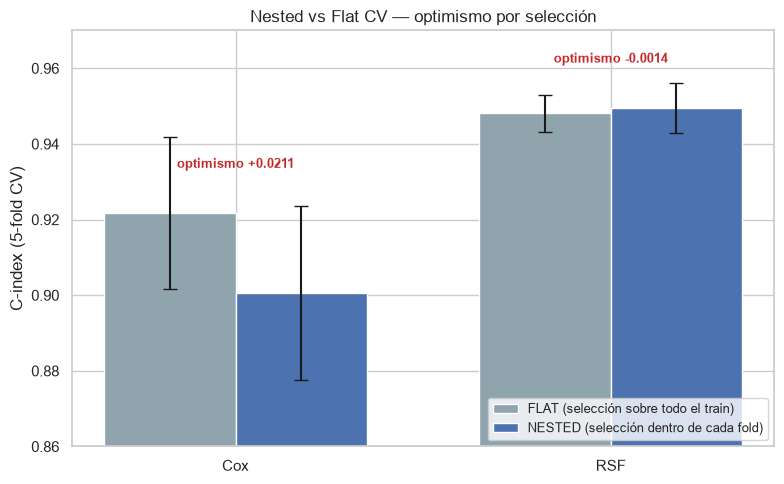

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(2); w = 0.35
flat_m = [np.mean(res["cox_flat"]), np.mean(res["rsf_flat"])]
nest_m = [np.mean(res["cox_nested"]), np.mean(res["rsf_nested"])]
ax.bar(x - w / 2, flat_m, w, yerr=[np.std(res["cox_flat"]), np.std(res["rsf_flat"])], capsize=5,
       color="#90A4AE", edgecolor="white", label="FLAT (selección sobre todo el train)")
ax.bar(x + w / 2, nest_m, w, yerr=[np.std(res["cox_nested"]), np.std(res["rsf_nested"])], capsize=5,
       color=C0, edgecolor="white", label="NESTED (selección dentro de cada fold)")
for i in range(2):
    ax.text(i, max(flat_m[i], nest_m[i]) + 0.012, f"optimismo {flat_m[i] - nest_m[i]:+.4f}",
            ha="center", color="#C62828", fontweight="bold", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(["Cox", "RSF"])
ax.set(ylim=(0.86, 0.97), ylabel="C-index (5-fold CV)", title="Nested vs Flat CV — optimismo por selección")
ax.legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR / "29_nested_cv.png", dpi=150, bbox_inches="tight")
plt.show()

El optimismo del RSF es prácticamente nulo (su selección es estable), y el del Cox es
pequeño. Conclusión: el ~0.95 **no** está inflado por la selección de features.

## 5.3 Adversarial validation

Entrenamos un clasificador para distinguir filas de train vs test. Si **no** lo logra
(AUC ≈ 0.5), las dos distribuciones son indistinguibles y el CV en train es un proxy
confiable del test.

AUC adversarial = 0.4329
train y test son indistinguibles -> CV confiable


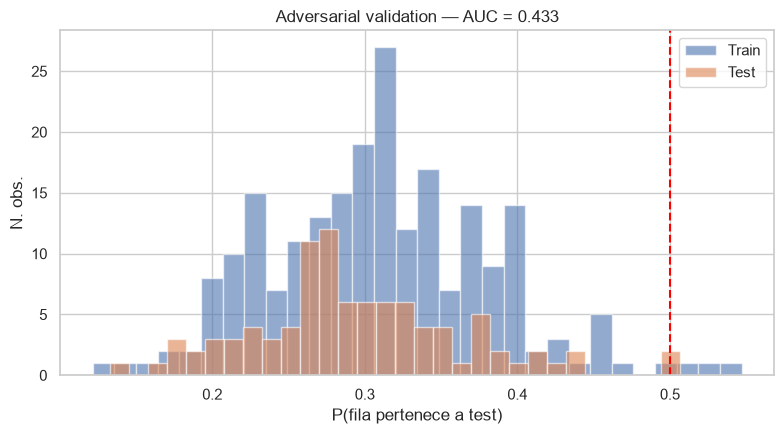

In [5]:
EXCLUDE = ["event_id", "event", "time_to_hit_hours"]
common = [c for c in df_test.columns if c in df_train.columns and c not in EXCLUDE]
X = pd.concat([df_train[common], df_test[common]], ignore_index=True).astype(float)
X = X.replace([np.inf, -np.inf], np.nan).fillna(X.median())
y_adv = np.r_[np.zeros(len(df_train)), np.ones(len(df_test))]

clf = RandomForestClassifier(n_estimators=400, min_samples_leaf=5, max_features="sqrt",
                             random_state=42, n_jobs=-1)
oof = cross_val_predict(clf, X, y_adv, cv=skf, method="predict_proba")[:, 1]
auc = roc_auc_score(y_adv, oof)
print(f"AUC adversarial = {auc:.4f}")
print("train y test son indistinguibles -> CV confiable" if auc < 0.6 else "hay drift -> precaución")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(oof[y_adv == 0], bins=30, alpha=0.6, color=C0, label="Train", edgecolor="white")
ax.hist(oof[y_adv == 1], bins=30, alpha=0.6, color=C1, label="Test", edgecolor="white")
ax.axvline(0.5, color="red", ls="--", lw=1.5)
ax.set(title=f"Adversarial validation — AUC = {auc:.3f}", xlabel="P(fila pertenece a test)", ylabel="N. obs.")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "28_adversarial_validation.png", dpi=150, bbox_inches="tight")
plt.show()

## 5.4 Predicciones por horizonte y monotonicidad

Generamos las predicciones de los 3 modelos sobre test y verificamos que
`prob_12h <= prob_24h <= prob_48h <= prob_72h` en cada incendio (coherencia de S(t)).

In [6]:
y_full = Surv.from_dataframe("event", "time_to_hit_hours", df_train)
preds = {}

# Cox
s = StandardScaler()
Xtr = pd.DataFrame(s.fit_transform(df_train[COX_FEATURES]), columns=COX_FEATURES)
Xtr["time_to_hit_hours"] = df_train["time_to_hit_hours"].values
Xtr["event"] = df_train["event"].values
cph = CoxPHFitter(penalizer=0.05).fit(Xtr, duration_col="time_to_hit_hours", event_col="event")
sf = cph.predict_survival_function(pd.DataFrame(s.transform(df_test[COX_FEATURES]), columns=COX_FEATURES), times=HORIZONS)
cox_p = df_test[["event_id"]].copy()
for h, col in zip(HORIZONS, HORIZON_COLS):
    cox_p[col] = np.clip(1 - sf.loc[h].values, 0, 1)
preds["Cox"] = cox_p

# RSF
rsf = RandomSurvivalForest(**RSF_PARAMS).fit(df_train[RSF_FEATURES].astype(float).values, y_full)
S = stepfn_to_matrix(rsf.predict_survival_function(df_test[RSF_FEATURES].astype(float).values), HORIZONS)
rsf_p = df_test[["event_id"]].copy()
for j, col in enumerate(HORIZON_COLS):
    rsf_p[col] = np.clip(1 - S[:, j], 0, 1)
preds["RSF"] = rsf_p

# KM
curve, edges = km_curves(df_train, HORIZONS)
te_q = assign_quartile(np.log1p(df_test["dist_min_ci_0_5h"].values), edges)
km_p = df_test[["event_id"]].copy()
for h, col in zip(HORIZONS, HORIZON_COLS):
    km_p[col] = np.clip([1 - curve[te_q[i]][h] for i in range(len(df_test))], 0, 1)
preds["KM"] = km_p

print("Monotonicidad (prob_12h <= ... <= prob_72h):")
for m, dfp in preds.items():
    worst = float(np.diff(dfp[HORIZON_COLS].values, axis=1).min())
    viol = int((np.diff(dfp[HORIZON_COLS].values, axis=1) < -1e-9).any(axis=1).sum())
    print(f"  {m:<4} caída máx = {worst:+.6f} | violan {viol}/{len(dfp)}")

Monotonicidad (prob_12h <= ... <= prob_72h):
  Cox  caída máx = +0.000000 | violan 0/95
  RSF  caída máx = +0.000000 | violan 0/95
  KM   caída máx = +0.000000 | violan 0/95


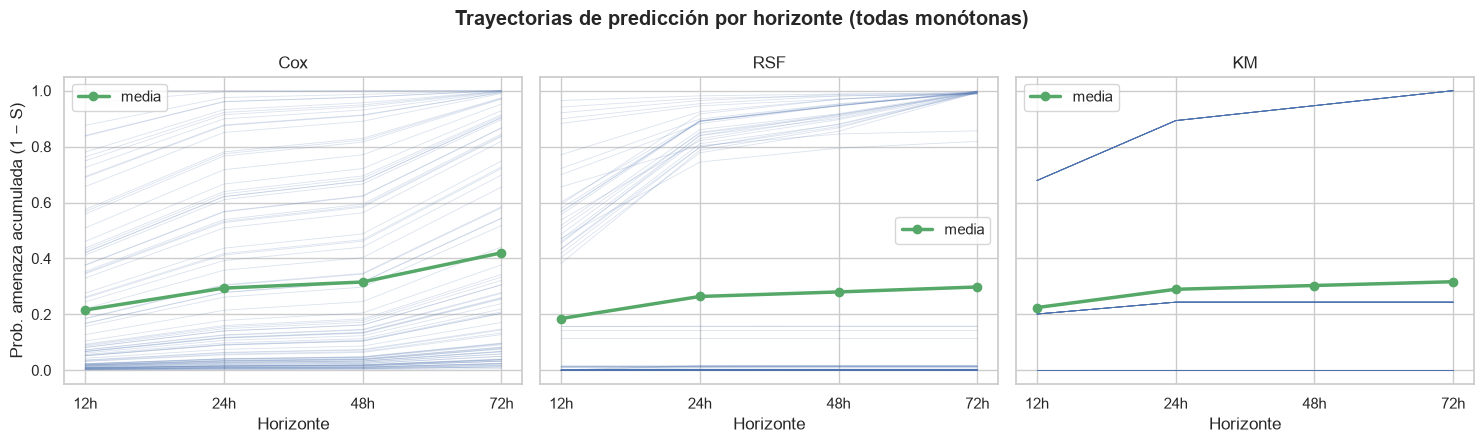

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
xpos = np.arange(len(HORIZONS))
for ax, (m, dfp) in zip(axes, preds.items()):
    P = dfp[HORIZON_COLS].values
    for i in range(len(P)):
        ax.plot(xpos, P[i], color=C0, alpha=0.2, lw=0.6)
    ax.plot(xpos, P.mean(axis=0), color=C2, lw=2.5, marker="o", label="media")
    ax.set_xticks(xpos); ax.set_xticklabels([f"{h}h" for h in HORIZONS])
    ax.set(title=m, xlabel="Horizonte")
    ax.legend()
axes[0].set_ylabel("Prob. amenaza acumulada (1 − S)")
plt.suptitle("Trayectorias de predicción por horizonte (todas monótonas)", fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "30_horizon_monotonicity.png", dpi=150, bbox_inches="tight")
plt.show()

## Resumen de la validación

- **RSF** mejor en C-index e IBS; **Cox** muy cerca y más interpretable; **KM** como referencia.
- **Optimismo de selección pequeño** (nested ≈ flat) → el ~0.95 es honesto.
- **AUC adversarial ≈ 0.5** → train y test indistinguibles, el CV transfiere al test.
- **Predicciones 100 % monótonas** en los tres modelos.

La defensa metodológica completa está en `decisiones.md`.